# Factor Extraction from S&P 500 Returns with PPCA

This notebook demonstrates **Probabilistic PCA (PPCA)** applied to monthly equity returns from the S&P 500.

The core challenge is simple: stocks enter and leave the index over time. A returns matrix starting from the year 2000 will naturally have large swaths of missing data — companies that weren't yet in the index, or that have since been removed. Imputing these upfront (e.g. with mean-fill) biases the covariance structure you're trying to learn.

PPCA solves this by treating missing values as latent variables and marginalising over them during the EM fitting loop. You get factor scores, loadings, and imputed returns all in one pass — no pre-processing required.

### What we'll cover
1. Fetching S&P 500 constituents and downloading price history
2. Inspecting the missingness pattern in the returns matrix
3. Fitting PPCA with a sign constraint on the first factor
4. Examining explained variance and the learned factor structure
5. Imputing missing monthly returns from the low-rank model

## Setup

We need `yfinance` for price data and `requests`/`pandas` for fetching the current index constituents from Wikipedia. Install them with:

```bash
pip install yfinance pandas requests
```

In [1]:
import io

import numpy as np
import pandas as pd
import requests
import yfinance as yf

from ppca import PPCA

## 1. Data

### 1.1 S&P 500 Constituents

We pull the current list of S&P 500 tickers from Wikipedia. Note that this gives us the *current* constituents — we're intentionally starting with a snapshot of today's index and looking backward, which is exactly what introduces survivorship-related missingness.

In [2]:
def sp500_tickers() -> list[str]:
    """Fetch current S&P 500 constituents from Wikipedia."""
    resp = requests.get(
        "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
        headers={"User-Agent": "Mozilla/5.0 (compatible; research/demo)"},
        timeout=10,
    )
    resp.raise_for_status()
    table = pd.read_html(io.StringIO(resp.text))[0]
    return table["Symbol"].str.replace(".", "-", regex=False).tolist()


tickers = sp500_tickers()
print(f"Found {len(tickers)} tickers.  First five: {tickers[:5]}")

Found 503 tickers.  First five: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']


### 1.2 Monthly Log Returns

We download daily adjusted closes and resample to **month-end log returns** (expressed in percent). To keep the download manageable and the factor model well-conditioned, we restrict to the **top 250 stocks by average daily dollar volume** over the past year — a simple liquidity filter that excludes micro-caps and thinly-traded names.

In [3]:
def monthly_returns(
    tickers: list[str],
    start: str = "2000-01-01",
    top_n: int | None = None,
    liquidity_lookback_days: int = 252,
) -> pd.DataFrame:
    """Download adjusted closes and resample to month-end log returns."""
    fields = ["Close", "Volume"] if top_n else ["Close"]
    data = yf.download(tickers, start=start, auto_adjust=True, progress=False)[fields]

    if top_n:
        close = data["Close"]
        volume = data["Volume"]
        dollar_vol = (close * volume).iloc[-liquidity_lookback_days:]
        top = dollar_vol.mean().nlargest(top_n).index
        px = close[top]
    else:
        px = data["Close"] if isinstance(data.columns, pd.MultiIndex) else data

    px = px.dropna(how="all", axis=1)
    return px.resample("ME").last().pipe(np.log).diff().iloc[1:] * 100.0


N_STOCKS = 250
print(f"Downloading data for {len(tickers)} tickers, keeping top {N_STOCKS} by liquidity...")
ret = monthly_returns(tickers, top_n=N_STOCKS)

print(f"\nReturns matrix: {ret.shape[0]} months × {ret.shape[1]} stocks")
print(f"Date range: {ret.index[0].date()} → {ret.index[-1].date()}")


Returns matrix: 313 months × 250 stocks
Date range: 2000-02-29 → 2026-02-28


## 2. Inspecting the Missingness Pattern

Before fitting, it's useful to see how much data is actually missing and whether the gaps have a discernible structure. We expect to see a block of missingness in the early 2000s (newly added names) and scattered gaps for stocks that had brief periods off the exchange.

In [4]:
mask = ret.isna().values

missing_pct = 100 * mask.mean()
missing_by_stock = mask.mean(axis=0).sort_values() if hasattr(mask.mean(axis=0), 'sort_values') else np.sort(mask.mean(axis=0))

print(f"Overall missingness:  {missing_pct:.1f}%")
print(f"Stocks with >50% missing: {(mask.mean(axis=0) > 0.5).sum()}")
print(f"Stocks with no missing:   {(mask.mean(axis=0) == 0).sum()}")

Overall missingness:  13.9%
Stocks with >50% missing: 28
Stocks with no missing:   167


## 3. Fitting PPCA

We fit a **12-component** PPCA model. Twelve factors is a reasonable choice for large-cap equity universes — the first captures broad market beta, and the remainder loosely correspond to sector and style tilts.


In [5]:
%%time

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from ppca import PPCA

x_train, x_test = train_test_split(ret, shuffle=False)

N_COMPONENTS = 12

ppca = PPCA(
    n_components=N_COMPONENTS,
    max_iterations=100,
    tol=1e-5,
    random_state=1234,
    l2_penalty=1.0,
    noise_type="diagonal",
)

pipe = make_pipeline(    
    RobustScaler(),
    ppca
)

mask = ~np.isfinite(x_train.values)

factors = pipe.fit_transform(x_train.values, ppca__missing_mask=mask)
print(f"Factor matrix shape: {factors.shape}  (months × components)")

/home/tingiskhan/python/ppca/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:1705: RuntimeWarning: All-NaN slice encountered
  self.center_ = np.nanmedian(X, axis=0)
/home/tingiskhan/python/ppca/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Factor matrix shape: (234, 12)  (months × components)
CPU times: user 349 ms, sys: 18.3 ms, total: 367 ms
Wall time: 393 ms


/home/tingiskhan/python/ppca/ppca/_ppca.py:136: RuntimeWarning: Mean of empty slice
  self.mean_ = np.nanmean(np.where(missing_mask, np.nan, X), axis=0)


## 4. Results

### 4.1 Explained Variance

The explained variance ratio tells us how much of the total cross-sectional variance each factor accounts for. In equity markets, the first factor (market) typically explains a large chunk, with subsequent factors contributing progressively less — a classic "scree" shape.

In [6]:
evr = pipe.named_steps["ppca"].explained_variance_ratio_

print("Explained variance by factor:")
print("-" * 35)
cumulative = 0.0
for i, v in enumerate(evr, start=1):
    cumulative += v
    print(f"  Factor {i:>2d}: {v:.3f}   (cumulative: {cumulative:.3f})")

print(f"\nTotal explained variance: {evr.sum():.3f}")

Explained variance by factor:
-----------------------------------
  Factor  1: 0.305   (cumulative: 0.305)
  Factor  2: 0.067   (cumulative: 0.372)
  Factor  3: 0.039   (cumulative: 0.411)
  Factor  4: 0.031   (cumulative: 0.442)
  Factor  5: 0.027   (cumulative: 0.469)
  Factor  6: 0.022   (cumulative: 0.491)
  Factor  7: 0.019   (cumulative: 0.510)
  Factor  8: 0.018   (cumulative: 0.528)
  Factor  9: 0.017   (cumulative: 0.544)
  Factor 10: 0.016   (cumulative: 0.560)
  Factor 11: 0.014   (cumulative: 0.575)
  Factor 12: 0.013   (cumulative: 0.587)

Total explained variance: 0.587


### 4.2 Reconstruction

Let's take an example and see how well it reconstructs AAPL

/home/tingiskhan/python/ppca/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(


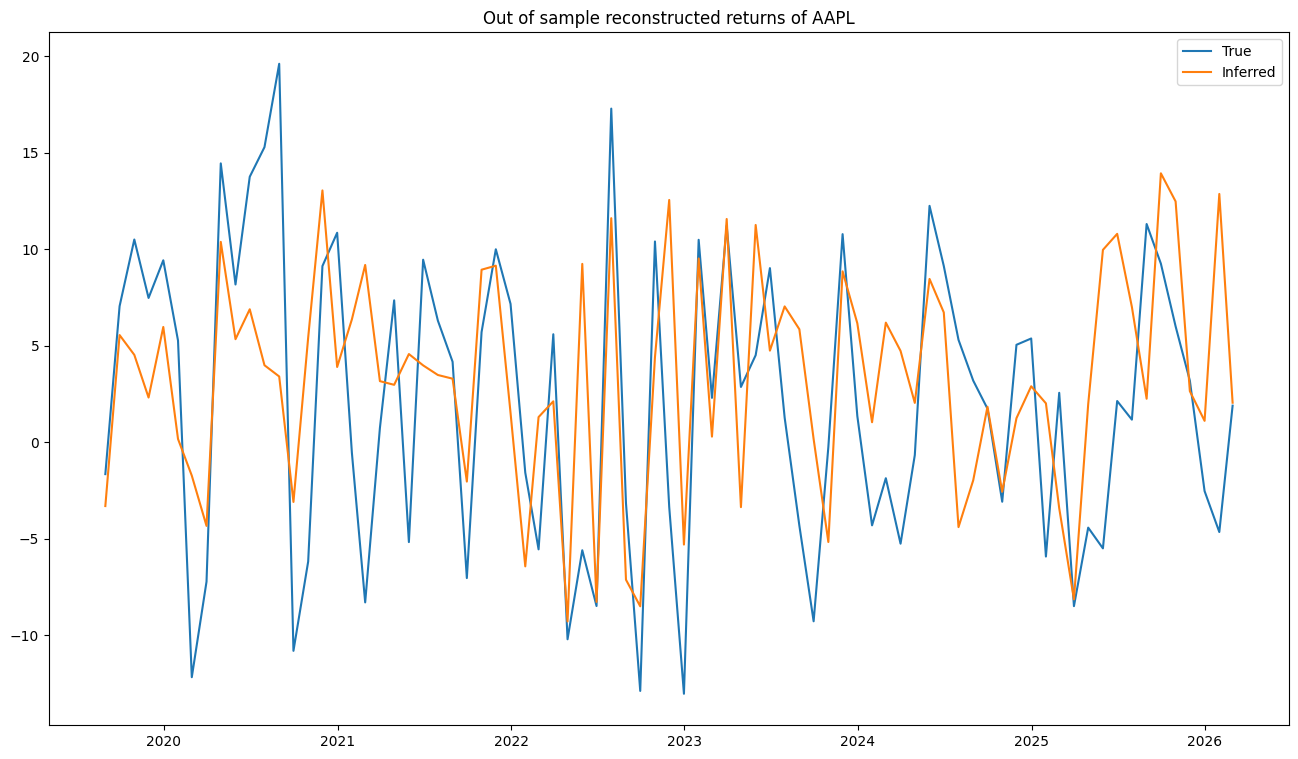

In [10]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16, 9)

factors_test = pipe.transform(x_test)

stock = "AAPL"
aapl_index = ret.columns.tolist().index(stock)

x_test_inferred = pipe.inverse_transform(factors_test)

fig, ax = plt.subplots()

ax.plot(x_test.index, x_test.values[:, aapl_index], label="True")
ax.plot(x_test.index, x_test_inferred[:, aapl_index], label="Inferred")

ax.set_title(f"Out of sample reconstructed returns of {stock}")
ax.legend()

## Summary

PPCA provides a principled, maximum-likelihood approach to factor modelling under incomplete data. The key advantages over a two-step impute-then-PCA approach are:

- **No imputation bias** — the EM algorithm marginalises over missing entries rather than substituting a fixed value.
- **Calibrated noise** — the model explicitly estimates the noise variance `σ²`, giving a probabilistic decomposition of signal and noise.